<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week2/Day2/ExerciseXP/exop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercice 1 : Détection et suppression des doublons

In [1]:
import pandas as pd

# Charger Titanic
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Avant suppression
print("Avant :", df.shape[0], "lignes")

# Trouver les doublons
print("Nombre de doublons :", df.duplicated().sum())

# Supprimer les doublons
df = df.drop_duplicates()

# Après suppression
print("Après :", df.shape[0], "lignes")

Avant : 891 lignes
Nombre de doublons : 0
Après : 891 lignes


Exercice 2 : Gestion des valeurs manquantes

In [2]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Charger Titanic
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Identifier les valeurs manquantes
print("=== Valeurs manquantes ===")
print(df.isnull().sum())

# Stratégie 1 : Supprimer les lignes avec valeurs manquantes
df_drop = df.dropna()
print(f"\nAprès dropna : {df_drop.shape[0]} lignes")

# Stratégie 2 : Remplir Age par la moyenne
df['Age'] = df['Age'].fillna(df['Age'].mean())
print(f"\nAge moyen utilisé : {df['Age'].mean():.2f}")

# Stratégie 3 : Remplir Cabin par valeur constante
df['Cabin'] = df['Cabin'].fillna('Inconnu')
print("\nCabin rempli avec 'Inconnu'")

# Stratégie 4 : Remplir Embarked par le mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print(f"\nEmbarked rempli avec le mode : {df['Embarked'].mode()[0]}")

# Stratégie 5 : SimpleImputer
imputer = SimpleImputer(strategy='mean')
df[['Age']] = imputer.fit_transform(df[['Age']])
print("\n SimpleImputer appliqué sur Age")

# Vérification finale
print("\n=== Valeurs manquantes après traitement ===")
print(df.isnull().sum())

=== Valeurs manquantes ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Après dropna : 183 lignes

Age moyen utilisé : 29.70

Cabin rempli avec 'Inconnu'

Embarked rempli avec le mode : S

 SimpleImputer appliqué sur Age

=== Valeurs manquantes après traitement ===
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


Exercice 3 : Ingénierie des fonctionnalités

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Charger Titanic
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# === Nouvelle fonctionnalité 1 : Family Size ===
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
print("=== Family Size ===")
print(df['Family_Size'].value_counts())

# === Nouvelle fonctionnalité 2 : Title ===
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.')
print("\n=== Titres extraits ===")
print(df['Title'].value_counts())

# Regrouper les titres rares
df['Title'] = df['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don',
     'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

print("\n=== Titres après regroupement ===")
print(df['Title'].value_counts())

# === Encodage One-Hot : Sex ===
df = pd.get_dummies(df, columns=['Sex'], drop_first=True)
print("\n=== One-Hot Encoding Sex ===")
print(df[['Sex_male']].head())

# === Label Encoding : Title ===
le = LabelEncoder()
df['Title'] = le.fit_transform(df['Title'])
print("\n=== Label Encoding Title ===")
print(df['Title'].value_counts())

# === Vérification finale ===
print("\n=== Nouvelles colonnes ===")
print(df[['Family_Size', 'Title', 'Sex_male']].head())

=== Family Size ===
Family_Size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

=== Titres extraits ===
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

=== Titres après regroupement ===
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

=== One-Hot Encoding Sex ===
   Sex_male
0      True
1     False
2     False
3     False
4      True

=== Label Encoding Title ===
Title
2    517
1    185
3    126
0     40
4     23
Name: count, dtype: int64

=== Nouvelles colonnes ===
   Family_Size  Title  Sex_male
0            2      2      True
1            2      3     False
2            1      1     False
3            2      3

Exercice 4 : Détection et traitement des valeurs aberrantes

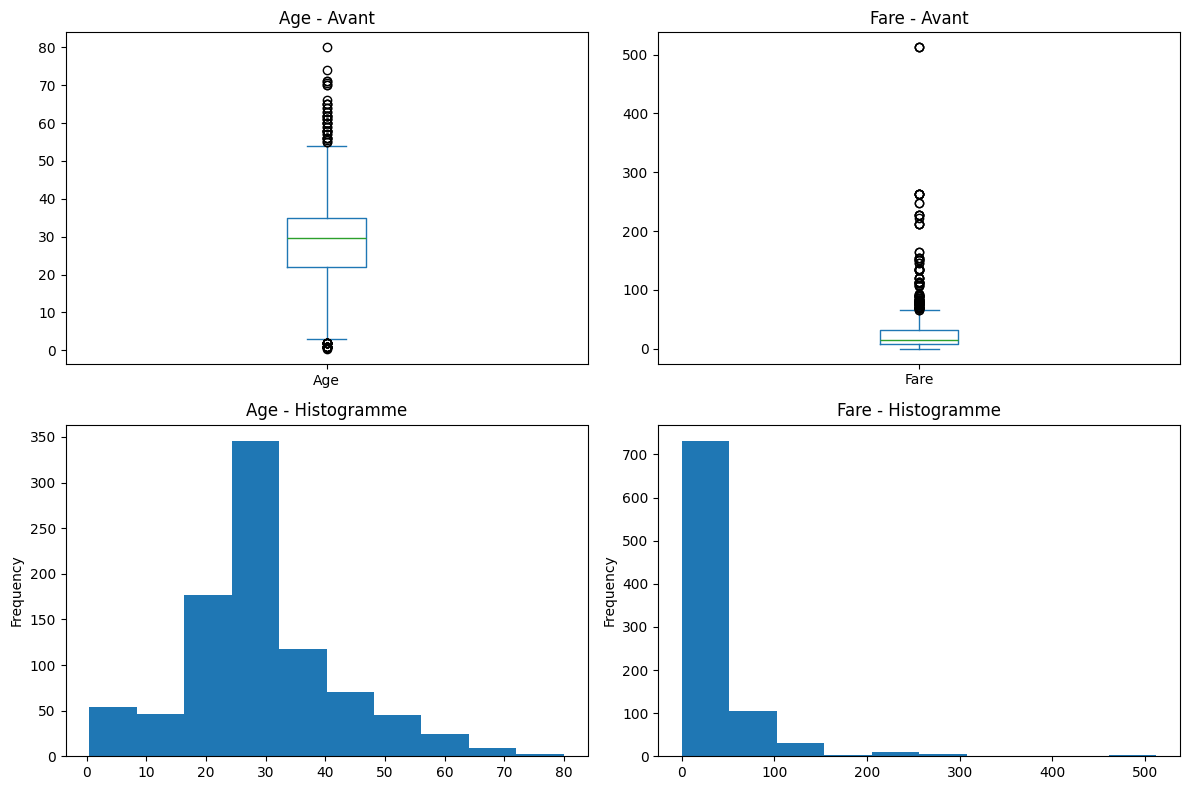

=== IQR Age ===
Valeurs aberrantes : 66
Lower : 2.50 | Upper : 54.50

=== IQR Fare ===
Valeurs aberrantes : 116
Lower : -26.72 | Upper : 65.63

Age plafonné à : 62.00
Fare max avant : 512.33
Fare_log max après : 6.24

Lignes avant suppression : 891
Lignes après suppression : 775


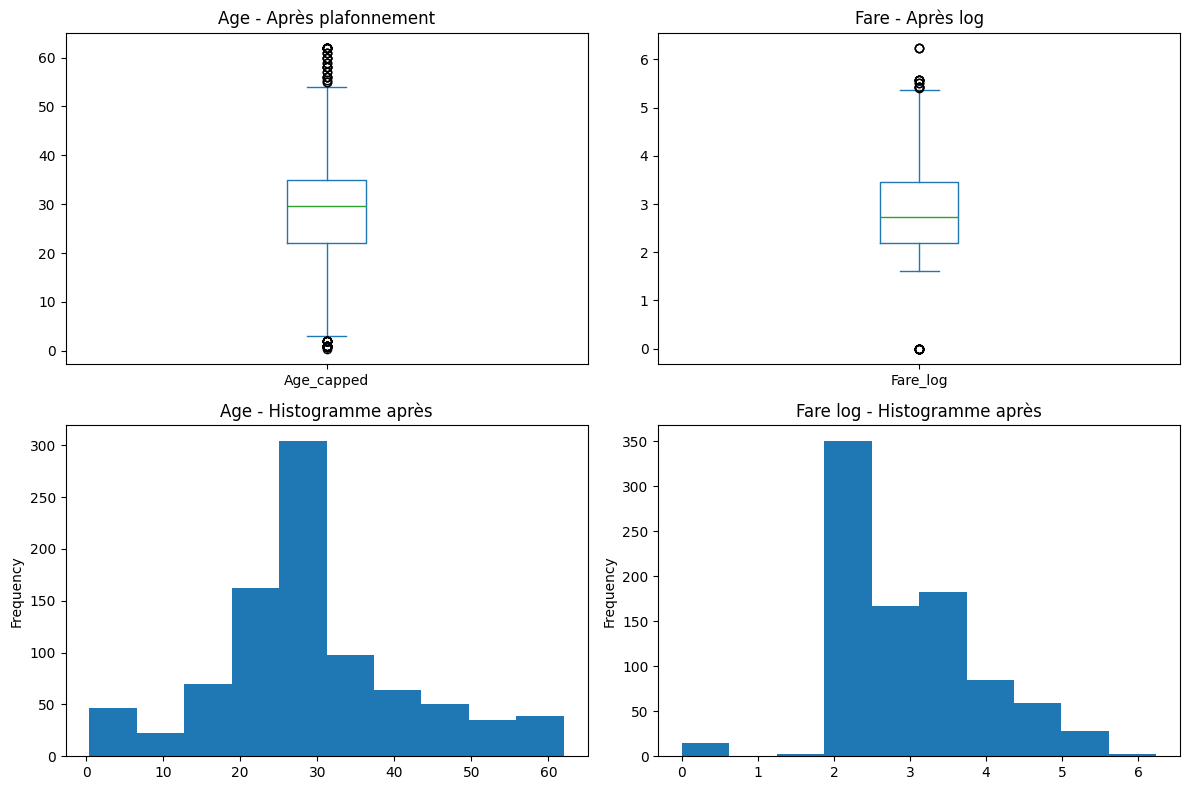


=== Comparaison Age ===
Avant - Max : 80.00
Après - Max : 62.00

=== Comparaison Fare ===
Avant - Max : 512.33
Après log - Max : 6.24


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger Titanic
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Remplir les valeurs manquantes d'Age
df['Age'] = df['Age'].fillna(df['Age'].mean())

# === Étape 1 : Visualisation AVANT ===
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df['Age'].plot(kind='box', ax=axes[0, 0], title='Age - Avant')
df['Fare'].plot(kind='box', ax=axes[0, 1], title='Fare - Avant')
df['Age'].plot(kind='hist', ax=axes[1, 0], title='Age - Histogramme')
df['Fare'].plot(kind='hist', ax=axes[1, 1], title='Fare - Histogramme')

plt.tight_layout()
plt.show()

# === Étape 2 : Détection IQR ===
def detect_outliers_iqr(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = col[(col < lower) | (col > upper)]
    print(f"Valeurs aberrantes : {len(outliers)}")
    print(f"Lower : {lower:.2f} | Upper : {upper:.2f}")
    return lower, upper

print("=== IQR Age ===")
lower_age, upper_age = detect_outliers_iqr(df['Age'])

print("\n=== IQR Fare ===")
lower_fare, upper_fare = detect_outliers_iqr(df['Fare'])

# === Étape 3 : Traitement ===

# Traitement 1 : Plafonnement Age (quantile 0.98)
age_cap = df['Age'].quantile(0.98)
df['Age_capped'] = df['Age'].clip(upper=age_cap)
print(f"\nAge plafonné à : {age_cap:.2f}")

# Traitement 2 : Transformation log Fare
df['Fare_log'] = np.log1p(df['Fare'])
print(f"Fare max avant : {df['Fare'].max():.2f}")
print(f"Fare_log max après : {df['Fare_log'].max():.2f}")

# Traitement 3 : Suppression lignes aberrantes Fare
df_clean = df[(df['Fare'] >= lower_fare) &
              (df['Fare'] <= upper_fare)]
print(f"\nLignes avant suppression : {df.shape[0]}")
print(f"Lignes après suppression : {df_clean.shape[0]}")

# === Étape 4 : Visualisation APRÈS ===
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df['Age_capped'].plot(kind='box', ax=axes[0, 0],
                      title='Age - Après plafonnement')
df['Fare_log'].plot(kind='box', ax=axes[0, 1],
                    title='Fare - Après log')
df['Age_capped'].plot(kind='hist', ax=axes[1, 0],
                      title='Age - Histogramme après')
df['Fare_log'].plot(kind='hist', ax=axes[1, 1],
                    title='Fare log - Histogramme après')

plt.tight_layout()
plt.show()

# === Comparaison finale ===
print("\n=== Comparaison Age ===")
print(f"Avant - Max : {df['Age'].max():.2f}")
print(f"Après - Max : {df['Age_capped'].max():.2f}")

print("\n=== Comparaison Fare ===")
print(f"Avant - Max : {df['Fare'].max():.2f}")
print(f"Après log - Max : {df['Fare_log'].max():.2f}")

Exercice 5 : Standardisation et normalisation des données

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Charger Titanic
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Remplir valeurs manquantes d'abord
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Traiter outliers Fare
df['Fare_log'] = np.log1p(df['Fare'])

# === StandardScaler sur Age ===
scaler = StandardScaler()
df['Age_scaled'] = scaler.fit_transform(df[['Age']])

print("=== StandardScaler - Age ===")
print(f"Moyenne : {df['Age_scaled'].mean():.2f}")
print(f"Écart-type : {df['Age_scaled'].std():.2f}")
print(df['Age_scaled'].head())

# === MinMaxScaler sur Fare_log ===
minmax = MinMaxScaler()
df['Fare_scaled'] = minmax.fit_transform(df[['Fare_log']])

print("\n=== MinMaxScaler - Fare ===")
print(f"Min : {df['Fare_scaled'].min():.2f}")
print(f"Max : {df['Fare_scaled'].max():.2f}")
print(df['Fare_scaled'].head())

# === Comparaison avant/après ===
print("\n=== Comparaison Age ===")
print(f"Avant - Min: {df['Age'].min():.2f}, Max: {df['Age'].max():.2f}")
print(f"Après - Min: {df['Age_scaled'].min():.2f}, Max: {df['Age_scaled'].max():.2f}")

print("\n=== Comparaison Fare ===")
print(f"Avant - Min: {df['Fare'].min():.2f}, Max: {df['Fare'].max():.2f}")
print(f"Après - Min: {df['Fare_scaled'].min():.2f}, Max: {df['Fare_scaled'].max():.2f}")

=== StandardScaler - Age ===
Moyenne : 0.00
Écart-type : 1.00
0   -0.592481
1    0.638789
2   -0.284663
3    0.407926
4    0.407926
Name: Age_scaled, dtype: float64

=== MinMaxScaler - Fare ===
Min : 0.00
Max : 1.00
0    0.338125
1    0.685892
2    0.350727
3    0.639463
4    0.352955
Name: Fare_scaled, dtype: float64

=== Comparaison Age ===
Avant - Min: 0.42, Max: 80.00
Après - Min: -2.25, Max: 3.87

=== Comparaison Fare ===
Avant - Min: 0.00, Max: 512.33
Après - Min: 0.00, Max: 1.00


Exercice 6 : Encodage des caractéristiques

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Charger Titanic
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Préparer les données d'abord
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna('Inconnu')

# Extraire Title
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.')
df['Title'] = df['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don',
     'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# === Identifier colonnes catégorielles ===
print("=== Colonnes catégorielles ===")
cat_cols = df.select_dtypes(include=['object']).columns
print(list(cat_cols))

# === One-Hot Encoding : Sex et Embarked ===
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
print("\n=== Après One-Hot Encoding ===")
print([col for col in df.columns if 'Sex' in col or 'Embarked' in col])

# === Label Encoding : Title ===
le = LabelEncoder()
df['Title_encoded'] = le.fit_transform(df['Title'])
print("\n=== Label Encoding Title ===")
print(df[['Title', 'Title_encoded']].drop_duplicates().sort_values('Title_encoded'))

# === Vérification finale ===
print("\n=== Colonnes finales ===")
print(df.dtypes)

print("\n=== Aperçu ===")
display(df.head())

=== Colonnes catégorielles ===
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Title']

=== Après One-Hot Encoding ===
['Sex_male', 'Embarked_Q', 'Embarked_S']

=== Label Encoding Title ===
     Title  Title_encoded
7   Master              0
2     Miss              1
0       Mr              2
1      Mrs              3
30    Rare              4

=== Colonnes finales ===
PassengerId        int64
Survived           int64
Pclass             int64
Name              object
Age              float64
SibSp              int64
Parch              int64
Ticket            object
Fare             float64
Cabin             object
Title             object
Sex_male            bool
Embarked_Q          bool
Embarked_S          bool
Title_encoded      int64
dtype: object

=== Aperçu ===


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Title,Sex_male,Embarked_Q,Embarked_S,Title_encoded
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,Inconnu,Mr,True,False,True,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,Mrs,False,False,False,3
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,Inconnu,Miss,False,False,True,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,Mrs,False,False,True,3
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,Inconnu,Mr,True,False,True,2


 Exercice 7 : Transformation des données pour la caractéristique Âge

In [8]:
import pandas as pd

# Charger Titanic
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Remplir valeurs manquantes Age
df['Age'] = df['Age'].fillna(df['Age'].mean())

# === Créer les groupes d'âge ===
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 60, 100],
    labels=['Enfant', 'Adolescent', 'Adulte', 'Senior']
)

print("=== Groupes d'âge ===")
print(df['Age_Group'].value_counts())

# === Aperçu ===
print("\n=== Aperçu Age vs Age_Group ===")
print(df[['Age', 'Age_Group']].head(10))

# === One-Hot Encoding ===
df = pd.get_dummies(df, columns=['Age_Group'], drop_first=True)

print("\n=== Colonnes après encodage ===")
age_cols = [col for col in df.columns if 'Age_Group' in col]
print(age_cols)

print("\n=== Aperçu final ===")
display(df[age_cols].head())

=== Groupes d'âge ===
Age_Group
Adulte        730
Adolescent     70
Enfant         69
Senior         22
Name: count, dtype: int64

=== Aperçu Age vs Age_Group ===
         Age   Age_Group
0  22.000000      Adulte
1  38.000000      Adulte
2  26.000000      Adulte
3  35.000000      Adulte
4  35.000000      Adulte
5  29.699118      Adulte
6  54.000000      Adulte
7   2.000000      Enfant
8  27.000000      Adulte
9  14.000000  Adolescent

=== Colonnes après encodage ===
['Age_Group_Adolescent', 'Age_Group_Adulte', 'Age_Group_Senior']

=== Aperçu final ===


,Age_Group_Adolescent,Age_Group_Adulte,Age_Group_Senior
0,False,True,False
1,False,True,False
2,False,True,False
3,False,True,False
4,False,True,False
